# Task 2 Model 1: Random Forest

This notebook loads the prepared data exported by Notebook 1, engineers visual features,
trains Random Forest, and exports only this model's artefacts.


## How to Run

Run `01_task2_setup.ipynb` once before this notebook. This notebook does not repeat the split,
image decoding, normalisation, or baseline work.


## 1. Setup


In [1]:
%matplotlib inline
import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance


In [2]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "pyproject.toml").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not find the repository root containing pyproject.toml")
sys.path.insert(0, str(REPO_ROOT))

from src.task2_utils import (
    ensure_task2_directories, per_class_table, prepared_namespace,
    random_forest_paths, restore_random_forest_checkpoint,
    result_frame, save_random_forest_checkpoint,
)
ensure_task2_directories()


### 1.1 Random Forest configuration


In [3]:
QUICK_RUN = False
RANDOM_STATE = 42
FEATURE_N_JOBS = -1
PERMUTATION_N_JOBS = 1
RF_N_ESTIMATORS = 100 if QUICK_RUN else 500
RF_MAX_DEPTH = 12
RF_MIN_SAMPLES_LEAF = 10
RF_MIN_SAMPLES_SPLIT = 20
RF_MAX_FEATURES = "sqrt"
MODEL_CONFIG = {
    "architecture": "random_forest", "n_estimators": RF_N_ESTIMATORS,
    "max_depth": RF_MAX_DEPTH, "min_samples_leaf": RF_MIN_SAMPLES_LEAF,
    "min_samples_split": RF_MIN_SAMPLES_SPLIT,
    "max_features": RF_MAX_FEATURES, "class_weight": "balanced_subsample",
    "random_state": RANDOM_STATE,
}
MODEL_PATH, SCORES_PATH = random_forest_paths()


## 2. Load Prepared Data from Notebook 1


In [4]:
data = prepared_namespace()
assert data.config.get("quick_run") == QUICK_RUN, (
    "QUICK_RUN does not match Notebook 1's prepared cache. "
    "Set the same value in both notebooks and rerun Notebook 1 if needed."
)
print(f"Loaded {len(data.train_frame):,} train and {len(data.validation_frame):,} validation rows")


Loaded 30,260 train and 7,566 validation rows


## 3. Train Random Forest


In [5]:
X_train_features = data.x_train_features
X_val_features = data.x_val_features
print("Loaded feature matrices:", X_train_features.shape, X_val_features.shape)

restored = restore_random_forest_checkpoint(data, MODEL_CONFIG)
random_forest = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF, 
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    max_features=RF_MAX_FEATURES,
    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
)
if restored is None:
    random_forest.fit(X_train_features, data.y_train)
    rf_scores = random_forest.predict_proba(X_val_features)
    save_random_forest_checkpoint(random_forest, rf_scores, data, MODEL_CONFIG)
else:
    random_forest, rf_scores = restored
    print("Restored compatible Random Forest checkpoint; fitting skipped")
rf_pred = random_forest.classes_[rf_scores.argmax(axis=1)]
display(result_frame(data.y_val, rf_pred, rf_scores, "Random Forest"))


Loaded feature matrices: (30260, 2007) (7566, 2007)
Random Forest: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_random_forest_scores.npz has an incompatible model configuration; refitting


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy
0,Random Forest,0.667724,0.684041,0.683212,0.668561,0.929553


### 3.1 Standard learning curve: training-data percentage

Each point fits a **fresh forest with the same hyperparameters** on a larger, nested,
class-stratified sample. Training macro-F1 is measured on that sample; validation
macro-F1 is measured on a fixed inner holdout drawn from the prepared training rows.
The original Task 2 validation set is reserved for final model evaluation above.

100% means the entire **inner training pool** (80% of the prepared training rows by
default), not all rows in the dataset. This is a single-split diagnostic, so small
fluctuations should not be interpreted as significant differences.

A large training/validation gap suggests overfitting. Low scores on both curves can
suggest underfitting or weak features. A validation curve still rising at the largest
size suggests that more training data may help. These are observations, not guarantees.

Edit the percentages below, then rerun the curve cells. Every point trains a separate
forest; this costs several fits. The curve uses the current RF configuration, including
its tree count. It does not modify the fitted final model or its checkpoint. Permutation
importance is a separate, potentially expensive analysis after these cells.

In [6]:
LEARNING_CURVE_FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]
LEARNING_CURVE_VALIDATION_FRACTION = 0.20
LEARNING_CURVE_SEED = RANDOM_STATE

In [7]:
import time
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split

fractions = np.asarray(LEARNING_CURVE_FRACTIONS, dtype=float)
if (fractions.ndim != 1 or not len(fractions) or not np.isfinite(fractions).all()
        or np.any(fractions <= 0) or np.any(fractions > 1)
        or np.any(np.diff(fractions) <= 0)):
    raise ValueError("Fractions must be strictly increasing and in (0, 1]")
if not 0 < LEARNING_CURVE_VALIDATION_FRACTION < 1:
    raise ValueError("Inner validation fraction must be in (0, 1)")
curve_pool, curve_holdout = train_test_split(
    np.arange(len(data.y_train)),
    test_size=LEARNING_CURVE_VALIDATION_FRACTION,
    stratify=data.y_train, random_state=LEARNING_CURVE_SEED,
)
rng = np.random.default_rng(LEARNING_CURVE_SEED)
# Shuffle each class once; prefixes ensure that larger samples contain smaller ones.
class_pools = [rng.permutation(curve_pool[data.y_train[curve_pool] == label])
               for label in range(data.n_classes)]
if any(len(pool) == 0 for pool in class_pools):
    raise ValueError("Every season must be present in the inner training pool")
curve_X_validation = data.x_train_features[curve_holdout]
curve_y_validation = data.y_train[curve_holdout]
curve_rows = []
for fraction in fractions:
    subset = np.concatenate([
        pool[:max(1, int(np.ceil(fraction * len(pool))))] for pool in class_pools
    ])
    curve_X_train = data.x_train_features[subset]
    curve_y_train = data.y_train[subset]
    curve_model = clone(random_forest)
    started = time.perf_counter()
    curve_model.fit(curve_X_train, curve_y_train)
    fit_seconds = time.perf_counter() - started
    train_scores = curve_model.predict_proba(curve_X_train)
    validation_scores = curve_model.predict_proba(curve_X_validation)
    train_predictions = train_scores.argmax(axis=1)
    validation_predictions = validation_scores.argmax(axis=1)
    row = {
        "training_percent": float(fraction * 100),
        "training_rows": len(subset), "validation_rows": len(curve_holdout),
        "train_log_loss": log_loss(
            curve_y_train, train_scores, labels=np.arange(data.n_classes),
        ),
        "validation_log_loss": log_loss(
            curve_y_validation, validation_scores, labels=np.arange(data.n_classes),
        ),
        "train_accuracy": accuracy_score(curve_y_train, train_predictions),
        "validation_accuracy": accuracy_score(curve_y_validation, validation_predictions),
        "train_macro_f1": f1_score(
            curve_y_train, train_predictions, average="macro",
            labels=np.arange(data.n_classes), zero_division=0,
        ),
        "validation_macro_f1": f1_score(
            curve_y_validation, validation_predictions, average="macro",
            labels=np.arange(data.n_classes), zero_division=0,
        ),
        "fit_seconds": fit_seconds,
    }
    curve_rows.append(row)
    print(f"{fraction:.0%}: {len(subset):,} rows, "
          f"train accuracy={row['train_accuracy']:.4f}, "
          f"validation accuracy={row['validation_accuracy']:.4f}, fit={fit_seconds:.1f}s")
    del curve_model
learning_curve_results = pd.DataFrame(curve_rows)
display(learning_curve_results)

10%: 2,423 rows, train accuracy=0.9253, validation accuracy=0.6363, fit=1.5s
25%: 6,054 rows, train accuracy=0.8936, validation accuracy=0.6566, fit=3.9s
50%: 12,104 rows, train accuracy=0.8560, validation accuracy=0.6631, fit=8.6s
75%: 18,158 rows, train accuracy=0.8239, validation accuracy=0.6657, fit=14.4s
100%: 24,208 rows, train accuracy=0.8092, validation accuracy=0.6699, fit=19.4s


,training_percent,training_rows,validation_rows,train_log_loss,validation_log_loss,train_accuracy,validation_accuracy,train_macro_f1,validation_macro_f1,fit_seconds
0,10.0,2423,6052,0.634838,0.907371,0.925299,0.636319,0.923697,0.601199,1.487109
1,25.0,6054,6052,0.638919,0.872197,0.893624,0.656642,0.899505,0.634624,3.942185
2,50.0,12104,6052,0.669000,0.856205,0.855998,0.663087,0.873389,0.658806,8.632141
3,75.0,18158,6052,0.690374,0.847270,0.823879,0.665730,0.848661,0.667712,14.367896
4,100.0,24208,6052,0.707050,0.845727,0.809237,0.669861,0.835955,0.671499,19.352399


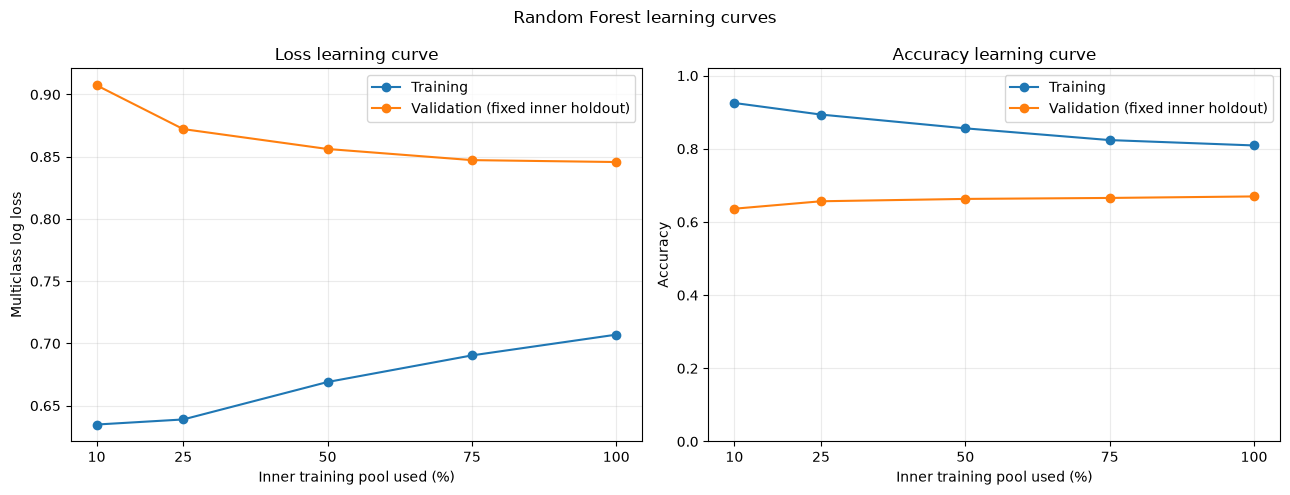

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = learning_curve_results["training_percent"]
for ax, metric, ylabel, title in [
    (axes[0], "log_loss", "Multiclass log loss", "Loss learning curve"),
    (axes[1], "accuracy", "Accuracy", "Accuracy learning curve"),
]: 
    ax.plot(x, learning_curve_results[f"train_{metric}"], marker="o", label="Training")
    ax.plot(x, learning_curve_results[f"validation_{metric}"], marker="o",
            label="Validation (fixed inner holdout)")
    ax.set(xlabel="Inner training pool used (%)", ylabel=ylabel, title=title)
    ax.set_xticks(x)
    if metric == "accuracy":
        ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle("Random Forest learning curves")
fig.tight_layout()
plt.show()

### 3.2 Feature evidence

Permutation importance is optional and can be much slower than fitting the forest because it evaluates every feature repeatedly. `PERMUTATION_N_JOBS` defaults to 1 to avoid nested process workers and the joblib worker warnings seen on macOS. Increase it only if the analysis is stable and memory pressure remains low.


In [9]:
importance = permutation_importance(
    random_forest, X_val_features, data.y_val, scoring="f1_macro",
    n_repeats=3 if QUICK_RUN else 8, random_state=RANDOM_STATE,
    n_jobs=PERMUTATION_N_JOBS,
)
feature_evidence = pd.DataFrame({
    "feature_index": np.arange(X_train_features.shape[1]),
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)
display(feature_evidence.head(20))
display(per_class_table(data.y_val, rf_pred, data.classes))


,feature_index,importance_mean,importance_std
1916,1916,0.001294,0.000528
1708,1708,0.001036,0.000132
2006,2006,0.001031,0.000370
1889,1889,0.001014,0.000613
170,170,0.000823,0.000581
143,143,0.000818,0.000461
946,946,0.000787,0.000290
2000,2000,0.000698,0.000077
1952,1952,0.000649,0.000445
828,828,0.000579,0.000456


,Season,Support,Precision,Recall,F1
0,Fall,2052,0.575492,0.640838,0.606410
1,Spring,312,0.860759,0.653846,0.743169
2,Summer,3732,0.748402,0.627278,0.682507
3,Winter,1470,0.622129,0.810884,0.704076


## 4. Export Random Forest Results


In [10]:
feature_path = MODEL_PATH.parent / "random_forest_feature_importance.csv"
feature_evidence.to_csv(feature_path, index=False)
print("Saved model:", MODEL_PATH)
print("Saved validation scores:", SCORES_PATH)
print("Run fingerprint:", data.fingerprint)


Saved model: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_random_forest.joblib
Saved validation scores: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_random_forest_scores.npz
Run fingerprint: 5f507c7bb57f
